Đọc file dữ liệu

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Walmart.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
0


Thống kê dữ liệu

In [2]:
# Kiểm tra các thông tin cơ bản của dữ liệu
print("Thông tin cơ bản về dữ liệu:")
print(df.info())

Thông tin cơ bản về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None


In [20]:
pd.set_option('display.max_columns', None)

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
# Thống kê mô tả (số liệu thống kê cơ bản)
print(f"\nThống kê mô tả (Dữ liệu được lấy từ {df['Date'].max()} đến {df['Date'].min()})")
print(df[['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].describe())
pd.reset_option('display.max_colwidth')


Thống kê mô tả (Dữ liệu được lấy từ 2012-10-26 00:00:00 đến 2010-02-05 00:00:00)
       Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price          CPI  \
count  6.435000e+03   6435.000000  6435.000000  6435.000000  6435.000000   
mean   1.046965e+06      0.069930    60.663782     3.358607   171.578394   
std    5.643666e+05      0.255049    18.444933     0.459020    39.356712   
min    2.099862e+05      0.000000    -2.060000     2.472000   126.064000   
25%    5.533501e+05      0.000000    47.460000     2.933000   131.735000   
50%    9.607460e+05      0.000000    62.670000     3.445000   182.616521   
75%    1.420159e+06      0.000000    74.940000     3.735000   212.743293   
max    3.818686e+06      1.000000   100.140000     4.468000   227.232807   

       Unemployment  
count   6435.000000  
mean       7.999151  
std        1.875885  
min        3.879000  
25%        6.891000  
50%        7.874000  
75%        8.622000  
max       14.313000  


C:\Users\OSC\AppData\Local\Temp\ipykernel_17820\13526201.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Weekly_Sales', data=total_sales_by_store, palette='viridis', legend=False)


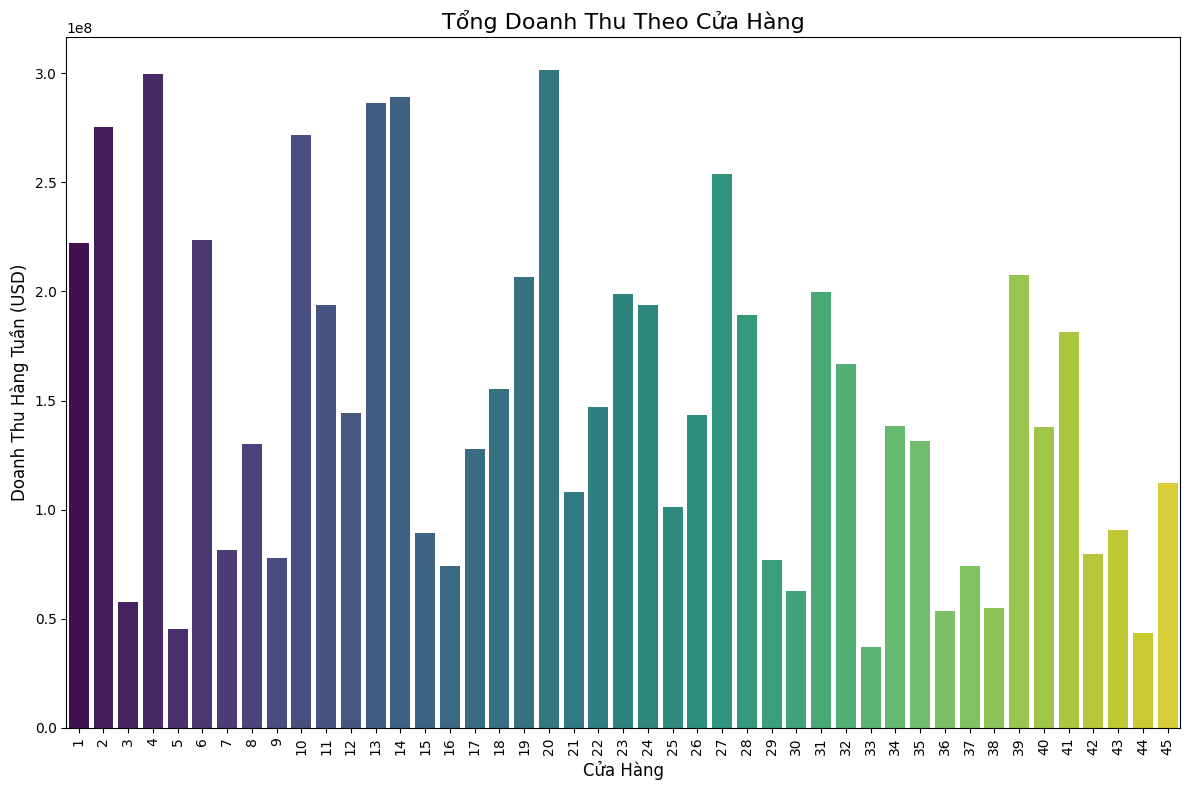

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính tổng doanh thu theo cửa hàng
total_sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().reset_index()

# Sắp xếp dữ liệu theo doanh thu giảm dần để dễ nhìn hơn
total_sales_by_store = total_sales_by_store.sort_values(by='Weekly_Sales', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))  # Kích thước hình ảnh
sns.barplot(x='Store', y='Weekly_Sales', data=total_sales_by_store, palette='viridis', legend=False)

# Thêm tiêu đề và nhãn
plt.title('Tổng Doanh Thu Theo Cửa Hàng', fontsize=16)
plt.xlabel('Cửa Hàng', fontsize=12)
plt.ylabel('Doanh Thu Hàng Tuần (USD)', fontsize=12)

# Hiển thị biểu đồ
plt.xticks(rotation=90)  # Xoay nhãn trên trục x nếu cần
plt.tight_layout()  # Cải thiện bố cục cho phù hợp
plt.show()


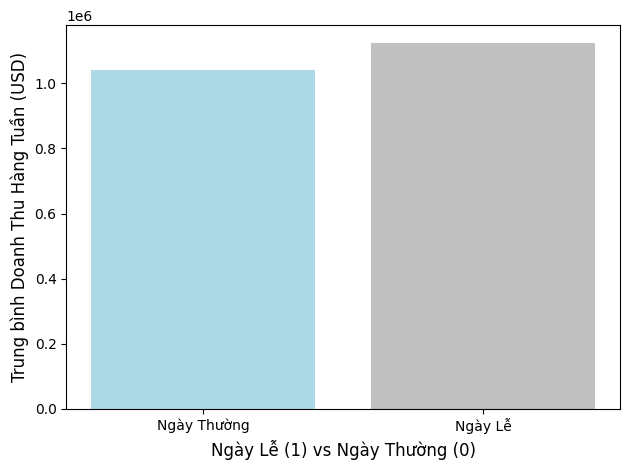

In [66]:
# Tính trung bình doanh thu theo ngày lễ vs ngày thường
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index()

# Vẽ biểu đồ so sánh doanh thu giữa ngày lễ và ngày thường
# Tạo nhãn tùy chỉnh
labels = ['Ngày Thường', 'Ngày Lễ']
values = holiday_sales.sort_values('Holiday_Flag')['Weekly_Sales']  # đảm bảo đúng thứ tự 0 -> 1 

plt.bar(labels, values, color=['lightblue', 'silver'])
plt.xlabel('Loại Ngày', fontsize=12)


# Thêm tiêu đề và nhãn
#plt.title('So Sánh Doanh Thu Ngày Lễ vs Ngày Thường', fontsize=16)
plt.xlabel('Ngày Lễ (1) vs Ngày Thường (0)', fontsize=12)
plt.ylabel('Trung bình Doanh Thu Hàng Tuần (USD)', fontsize=12)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

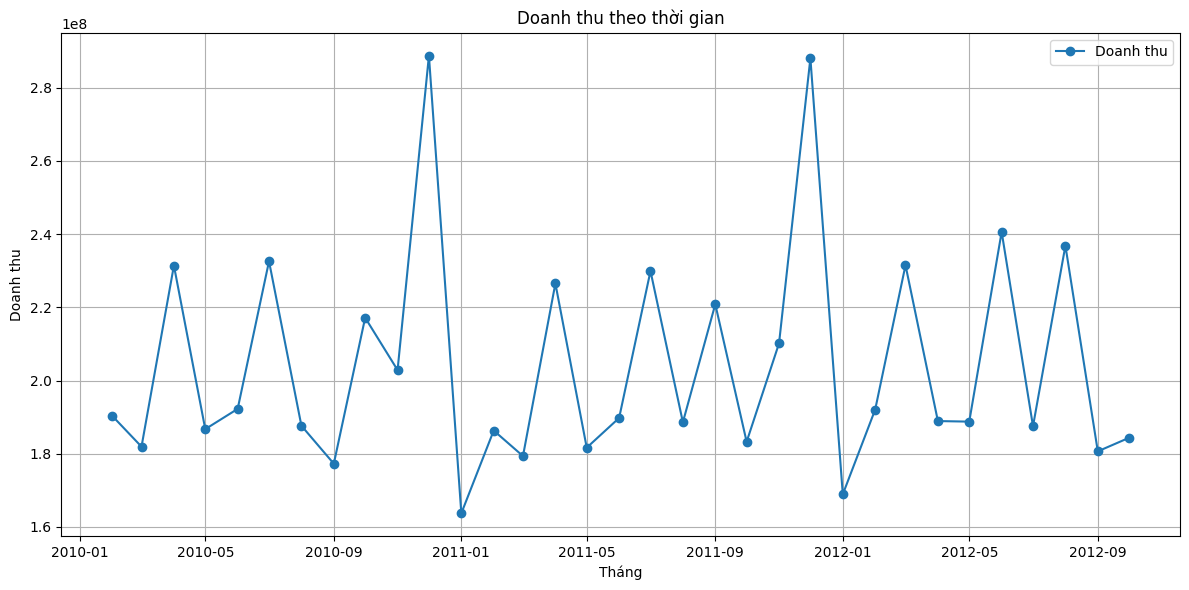

In [3]:
# Chuyển cột 'date' về kiểu datetime
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

# Tạo cột 'month' để nhóm theo tháng
df['month'] = df['Date'].dt.to_period("M")

#Nhóm dữ liệu theo tháng và tính tổng doanh thu
monthly_sales = df.groupby('month')['Weekly_Sales'].sum().reset_index()

#Chuyển về dạng datetime để vẽ biểu đồ
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()

#vẽ biểu đồ
plt.figure(figsize=(12,6))
plt.title("Doanh thu theo thời gian")
plt.plot(monthly_sales['month'], monthly_sales['Weekly_Sales'], marker = 'o', label='Doanh thu')
plt.xlabel("Tháng")
plt.ylabel("Doanh thu")
plt.grid(visible=True, linewidth = 0.8)
plt.legend()
plt.tight_layout()
plt.show()

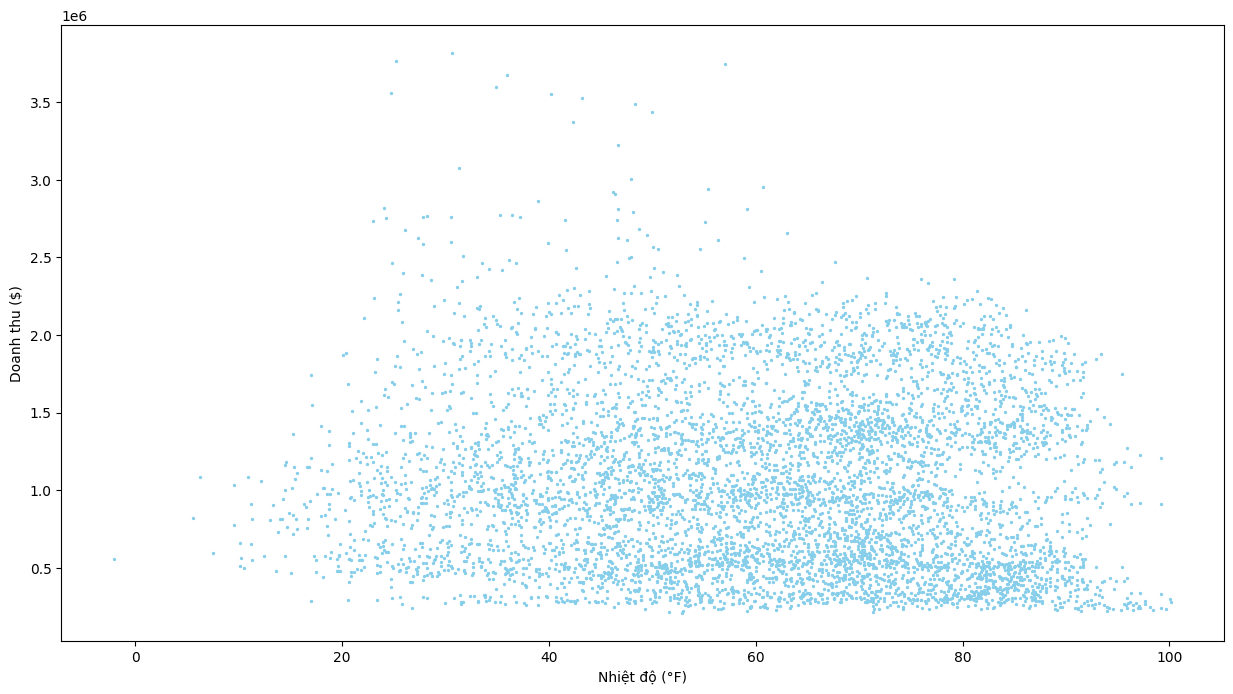

In [15]:
plt.figure(figsize=(15,8))
plt.scatter(df['Temperature'], df['Weekly_Sales'], color='skyblue', s=2)
plt.xlabel('Nhiệt độ (°F)')
plt.ylabel("Doanh thu ($)")
plt.tight_layout
plt.show()

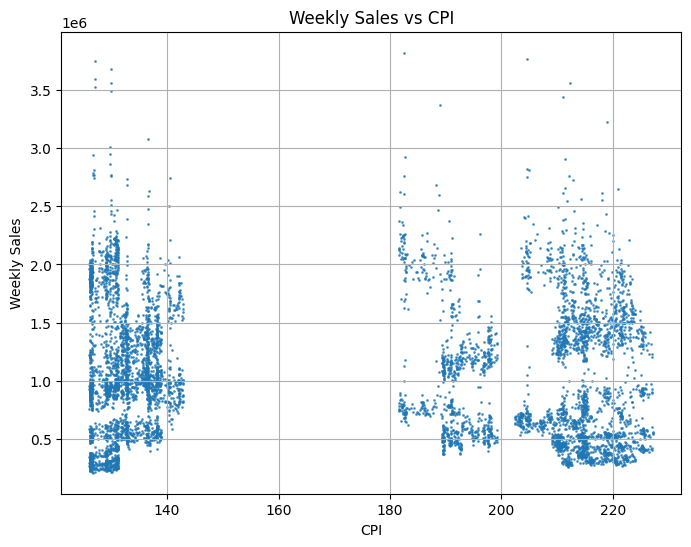

In [29]:
# Vẽ scatter plot giữa CPI và Weekly_Sales
plt.figure(figsize=(8, 6))
plt.scatter(df['CPI'], df['Weekly_Sales'], alpha=0.7, s=1)

plt.title('Weekly Sales vs CPI')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

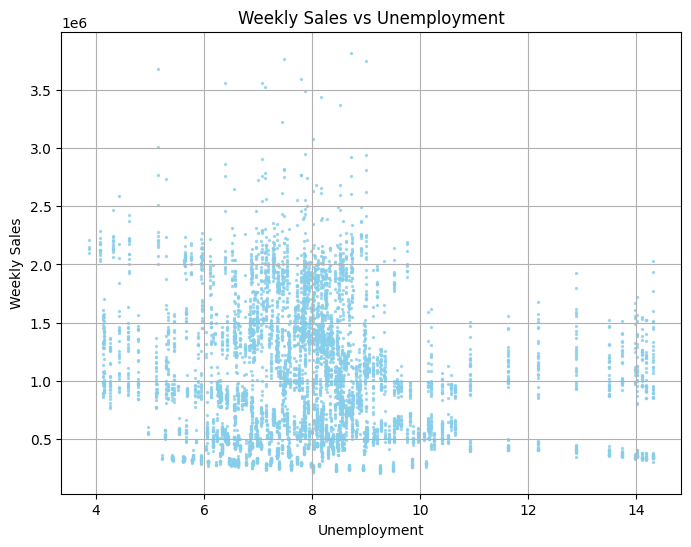

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Unemployment'], df['Weekly_Sales'],color = 'skyblue', alpha=0.7, s=2)

plt.title('Weekly Sales vs Unemployment')
plt.xlabel('Unemployment')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()


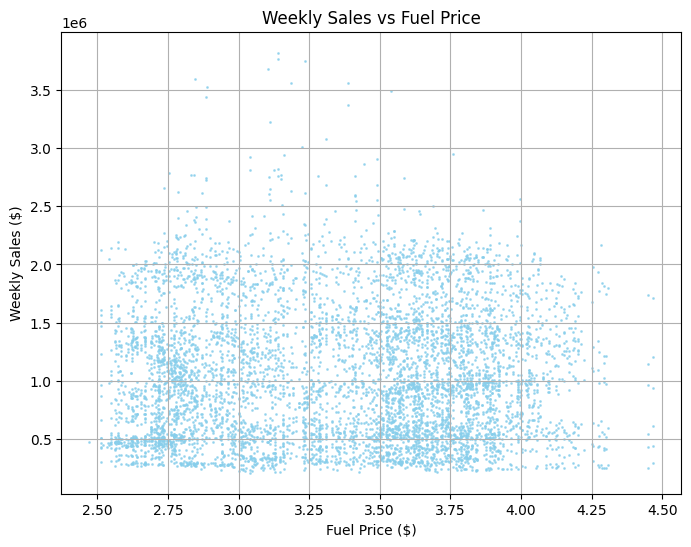

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Fuel_Price'], df['Weekly_Sales'], color='skyblue', alpha=0.7, s=1)

plt.title('Weekly Sales vs Fuel Price')
plt.xlabel('Fuel Price ($)')
plt.ylabel('Weekly Sales ($)')
plt.grid(True)
plt.show()